In [ ]:
# Skin Condition

Found 2394 files belonging to 6 classes.
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.4135 - loss: 1.5903 - val_accuracy: 0.7455 - val_loss: 0.7930
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.7357 - loss: 0.7561 - val_accuracy: 0.8125 - val_loss: 0.4776
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.7831 - loss: 0.6008 - val_accuracy: 0.8393 - val_loss: 0.4668
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8249 - loss: 0.5220 - val_accuracy: 0.8214 - val_loss: 0.5134
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8519 - loss: 0.4557 - val_accuracy: 0.8973 - val_loss: 0.3758
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8597 - loss: 0.3989 - val_accuracy: 0.8750 - val_loss: 0.3316
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.8754 - loss: 0.3788 - val_accuracy: 0.8884 - val_loss: 0.3431
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.8934 

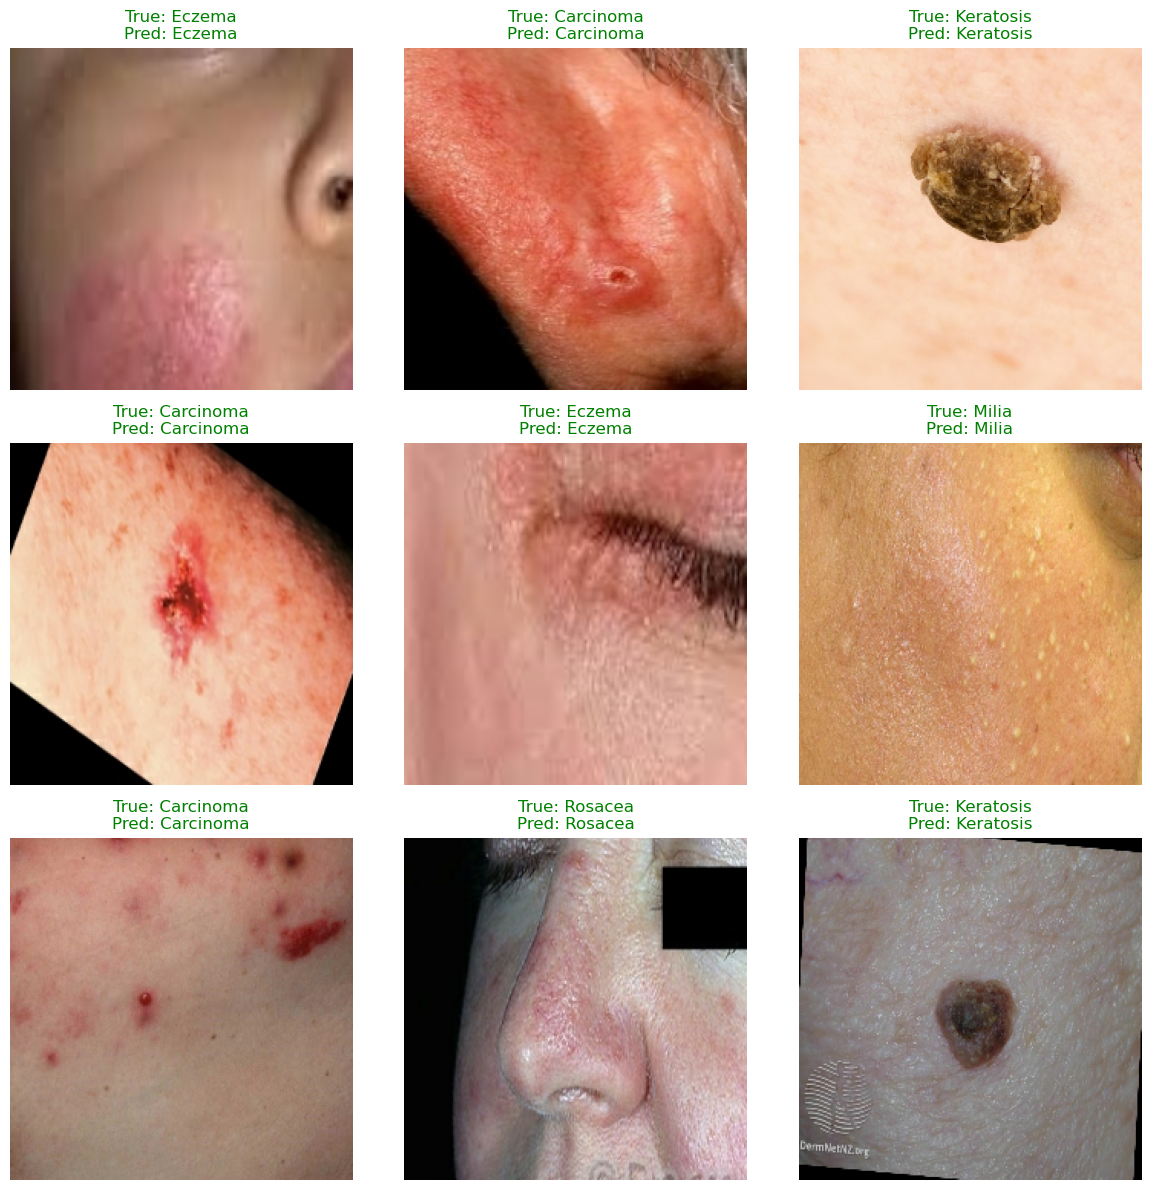

In [1]:
import numpy as np
import pandas as pd
import os

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory


# Update the directory path
dataset_dir = 'C:/Users/KIIT/Desktop/skin_aug_16_sep/Skin_Conditions'

dataset = image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

def split_dataset(dataset, train_size=0.8, val_size=0.1, test_size=0.1):
    total_size = len(dataset)
    train_end = int(total_size * train_size)
    val_end = train_end + int(total_size * val_size)
    
    train_dataset = dataset.take(train_end)
    val_dataset = dataset.skip(train_end).take(val_end - train_end)
    test_dataset = dataset.skip(val_end)
    
    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = split_dataset(dataset)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

def augment_data(dataset):
    def augment(image, label):
        image = data_augmentation(image)
        return image, label

    return dataset.map(augment)

train_dataset = augment_data(train_dataset)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    batch_size=32
)

test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_fine_tune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    batch_size=32
)

test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

import matplotlib.pyplot as plt

class_names = [
    'Acne',
    'Carcinoma',
    'Eczema',
    'Keratosis',
    'Milia',
    'Rosacea'
]

def plot_random_images(test_dataset, model, class_names, num_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    for image_batch, label_batch in test_dataset.take(1):
        predictions = model.predict(image_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        indices = np.random.choice(len(image_batch), num_images, replace=False)
        
        for idx, ax in enumerate(axes):
            img = image_batch[indices[idx]].numpy().astype(np.uint8)
            true_label = label_batch[indices[idx]].numpy()
            pred_label = predicted_labels[indices[idx]]
            
            ax.imshow(img)
            ax.axis('off')
            
            true_label_name = class_names[true_label]
            pred_label_name = class_names[pred_label]
            title_color = 'green' if true_label == pred_label else 'red'
            ax.set_title(f"True: {true_label_name}\nPred: {pred_label_name}", color=title_color, fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_random_images(test_dataset, model, class_names)

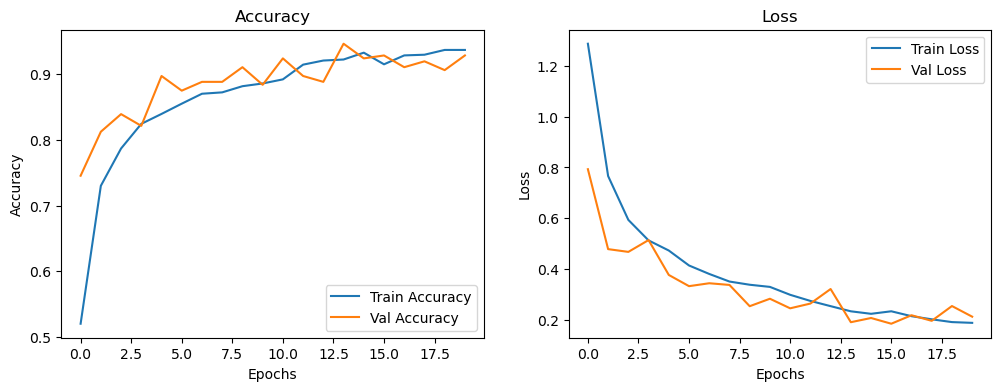

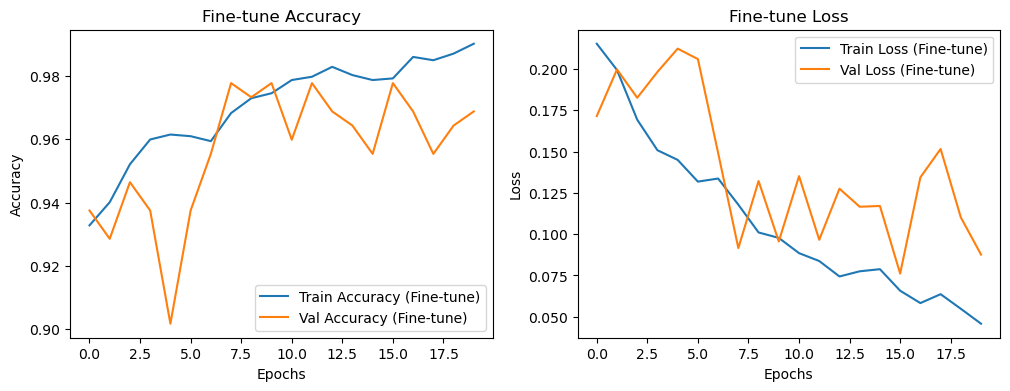

In [3]:
# # Your existing code continues here...

# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     batch_size=32
# )

# test_loss, test_acc = model.evaluate(test_dataset)
# print(f"Test Accuracy: {test_acc:.4f}")

# base_model.trainable = True
# for layer in base_model.layers[:-20]:
#     layer.trainable = False

# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# history_fine_tune = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=20,
#     batch_size=32
# )

# test_loss, test_acc = model.evaluate(test_dataset)
# print(f"Test Accuracy: {test_acc:.4f}")

# # Now, add the plotting code for training and validation accuracy/loss here:

# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Fine-tuning plot (optional)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'], label='Train Accuracy (Fine-tune)')
plt.plot(history_fine_tune.history['val_accuracy'], label='Val Accuracy (Fine-tune)')
plt.title('Fine-tune Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'], label='Train Loss (Fine-tune)')
plt.plot(history_fine_tune.history['val_loss'], label='Val Loss (Fine-tune)')
plt.title('Fine-tune Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
